# Pipeline Loader Test

This notebook verifies the functionality of the new `src.pipeline.loader` module.
We will test loading both building data (U01) and weather data (ERA5 & Keskkonnaportaal).

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
# Ensure project root is in path
sys.path.append(str(Path.cwd()))

from src.pipeline import loader, config
import pandas as pd
import matplotlib.pyplot as plt

## 1. Test Weather Loading (ERA5)

ERA5 Loaded: (36216, 14)
                     t2m  d2m  u10  v10  ssrd  tp  sf  tcc  lcc  mcc  hcc  \
time                                                                        
2021-12-31 01:00:00  NaN  NaN  NaN  NaN   NaN NaN NaN  NaN  NaN  NaN  NaN   
2021-12-31 02:00:00  NaN  NaN  NaN  NaN   NaN NaN NaN  NaN  NaN  NaN  NaN   
2021-12-31 03:00:00  NaN  NaN  NaN  NaN   NaN NaN NaN  NaN  NaN  NaN  NaN   
2021-12-31 04:00:00  NaN  NaN  NaN  NaN   NaN NaN NaN  NaN  NaN  NaN  NaN   
2021-12-31 05:00:00  NaN  NaN  NaN  NaN   NaN NaN NaN  NaN  NaN  NaN  NaN   

                     solar_irradiance  temp_out  wind_speed  
time                                                         
2021-12-31 01:00:00               NaN       NaN         NaN  
2021-12-31 02:00:00               NaN       NaN         NaN  
2021-12-31 03:00:00               NaN       NaN         NaN  
2021-12-31 04:00:00               NaN       NaN         NaN  
2021-12-31 05:00:00               NaN       NaN         NaN  


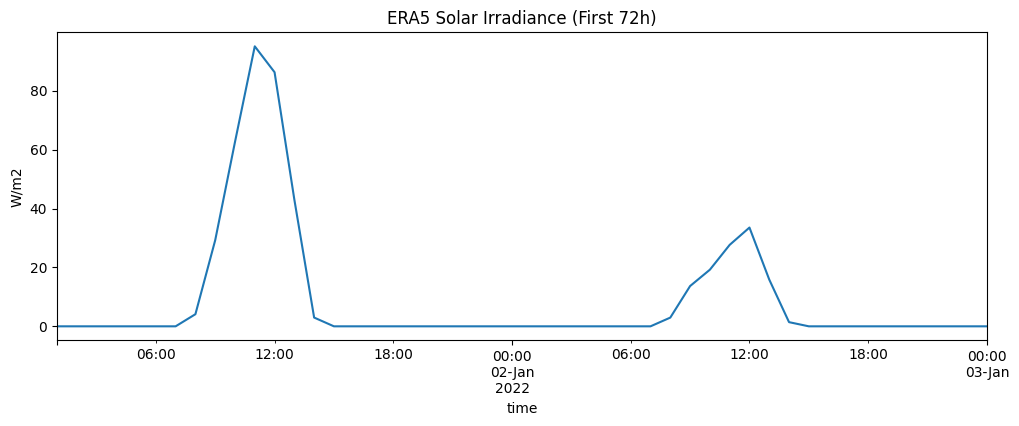

In [3]:
try:
    era5_df = loader.load_weather_data(source="era5")
    print("ERA5 Loaded:", era5_df.shape)
    print(era5_df.head())
    
    # Plot to verify solar radiation looks valid (no negative spikes, correct day/night)
    plt.figure(figsize=(12, 4))
    era5_df[config.COL_SOLAR].iloc[24:72].plot(title="ERA5 Solar Irradiance (First 72h)")
    plt.ylabel("W/m2")
    plt.show()
    
except Exception as e:
    print("ERA5 Loading Failed:", e)

## 2. Test Building Data Loading (U06 - Library/Economics)

In [7]:
# Note: Need to make sure we have the metadata excel files available
# loader.load_building_data might fail if it relies on files not present in the simplified path

building_code = "U06"
try:
    # Attempt loading. Note: the internal implementation needs to match your folder structure
    # U06/2022/U06_...csv
    df = loader.load_building_data(building_code, verbose=True)
    print(f"{building_code} Loaded:", df.shape)
    print(df.head())
    
    if config.COL_HEAT in df.columns:
        df[config.COL_HEAT].plot(figsize=(12,4), title=f"{building_code} Heat Consumption")
    
except Exception as e:
    print(f"Building {building_code} Loading Failed:", e)
    import traceback
    traceback.print_exc()

Discovered measurement points for U06: ['BHB01', 'BHB02', 'BHB03', 'BHB04', 'BHB05', 'BHB06']
U06 Loaded: (26275, 14)
                 time    BHB01_näit  BHB02_näit  BHB03_näit  BHB04_näit  \
0 2022-01-01 00:00:00  11305.785000         NaN         NaN         NaN   
1 2022-01-01 01:00:00  11306.010000         NaN         NaN         NaN   
2 2022-01-01 02:00:00  11306.180000         NaN         NaN         NaN   
3 2022-01-01 03:00:00  11306.420000         NaN         NaN         NaN   
4 2022-01-01 04:00:00  11306.623333         NaN         NaN         NaN   

   BHB05_näit  BHB06_näit  BHB01_measurement_delta_kwh  \
0         NaN         NaN                          NaN   
1         NaN         NaN                     0.225000   
2         NaN         NaN                     0.170000   
3         NaN         NaN                     0.240000   
4         NaN         NaN                     0.203333   

   BHB02_measurement_delta_kwh  BHB03_measurement_delta_kwh  \
0                  